In [1]:
# Load tests from results folder
import pickle, os

SYMBOL = 'SOLUSDC'

DIR = f'/_data/base/{SYMBOL}/results'
assert os.path.isdir(DIR), f'Results folder not found: {DIR}'

files = [fn for fn in os.listdir(DIR) if fn.endswith('.pkl')]
files.sort()
assert len(files) > 0, f'No result files in: {DIR}'

sizes_mb = 0.0
count = 0

test_data: list = []

for fn in files:
    path = f'{DIR}/{fn}'
    assert os.path.isfile(path), f'Not a file: {path}'
    size_mb = os.path.getsize(path) / 1024 / 1024
    with open(path, 'rb') as f:
        data = pickle.load(f)
    assert isinstance(data, list), f'File is not a list: {path}'
    test_data.extend(data)
    sizes_mb += size_mb
    count += len(data)
    print(f'Loaded {len(data)} tests from {fn} ({size_mb:.3f} MB)')

print(f'Total size: {sizes_mb:.3f} MB')
print(f'Loaded total: {len(test_data)} tests from {len(files)} files')

Loaded 19664 tests from SOLUSDC.mass_test.w0.pkl (4.747 MB)
Loaded 19676 tests from SOLUSDC.mass_test.w1.pkl (4.750 MB)
Loaded 19701 tests from SOLUSDC.mass_test.w10.pkl (4.757 MB)
Loaded 19696 tests from SOLUSDC.mass_test.w11.pkl (4.755 MB)
Loaded 19689 tests from SOLUSDC.mass_test.w12.pkl (4.752 MB)
Loaded 19682 tests from SOLUSDC.mass_test.w13.pkl (4.752 MB)
Loaded 19694 tests from SOLUSDC.mass_test.w14.pkl (4.754 MB)
Loaded 19684 tests from SOLUSDC.mass_test.w15.pkl (4.752 MB)
Loaded 19659 tests from SOLUSDC.mass_test.w16.pkl (4.745 MB)
Loaded 19646 tests from SOLUSDC.mass_test.w17.pkl (4.742 MB)
Loaded 19698 tests from SOLUSDC.mass_test.w18.pkl (4.755 MB)
Loaded 19708 tests from SOLUSDC.mass_test.w19.pkl (4.758 MB)
Loaded 19705 tests from SOLUSDC.mass_test.w2.pkl (4.757 MB)
Loaded 19673 tests from SOLUSDC.mass_test.w20.pkl (4.750 MB)
Loaded 19643 tests from SOLUSDC.mass_test.w21.pkl (4.742 MB)
Loaded 19673 tests from SOLUSDC.mass_test.w22.pkl (4.749 MB)
Loaded 19687 tests from SOL

In [2]:
# Plot helpers
import numpy as np, matplotlib.pyplot as plt

# Plot pairs
def np_sma(a, period):
    sma = np.full(len(a), np.nan)

    for i in range(period - 1, len(a)):
        sma[i] = np.mean(a[i - period + 1:i + 1])

    return sma


def plot_pairs(pairs, title, log_x=True):
    pairs.sort(key=lambda x: x[0])

    x = np.array([p[0] for p in pairs])
    y = np.array([p[1] for p in pairs])
    
    if log_x:
        x = np.log(x)
    y = np_sma(y, max(2, int(len(y) / 50)))

    plt.clf()
    plt.figure(figsize=(16, 8))
    plt.plot(x, y)
    plt.title(title)
    plt.show()


<Figure size 640x480 with 0 Axes>

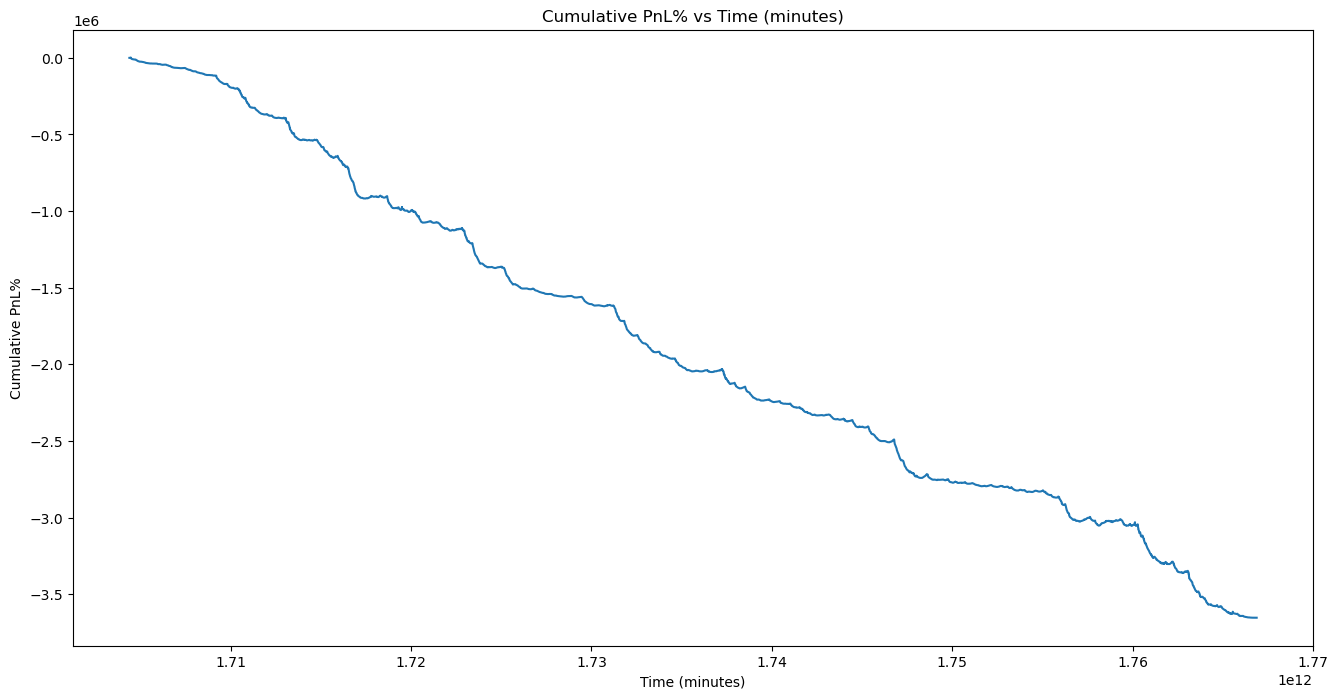

In [3]:
# Test diff map
d_map = {}

for item in test_data:
    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    vol = float(rc['test_volume_usd'])
    pnl = float(agg['pnl'])
    t = item['start_time_ms']

    t = int(t / 60_000) * 60_000
    
    if t not in d_map:
        d_map[t] = 0

    d_map[t] += pnl / vol * 100

date, line = [], []
s = 0

for t in sorted(d_map.keys()):
    s += d_map[t]
    date.append(t)
    line.append(s)

plt.clf()
plt.figure(figsize=(16, 8))
plt.plot(date, line)
plt.title('Cumulative PnL% vs Time (minutes)')
plt.xlabel('Time (minutes)')
plt.ylabel('Cumulative PnL%')
plt.show() 

<Figure size 640x480 with 0 Axes>

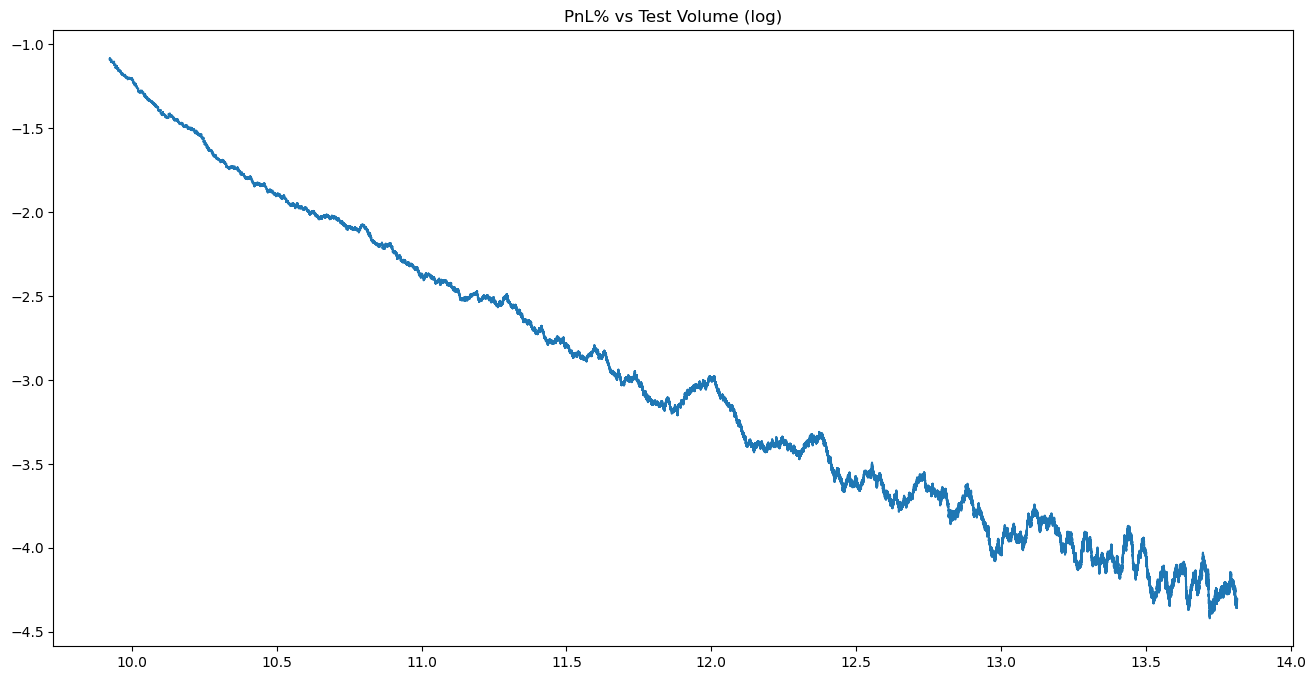

In [4]:
# General volume to pnl plot
pairs = []

for item in test_data:
    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    vol = float(rc['test_volume_usd'])
    pnl = float(agg['pnl'])

    pairs.append((vol, pnl / vol * 100))

plot_pairs(pairs, title='PnL% vs Test Volume (log)', log_x=True)


<Figure size 640x480 with 0 Axes>

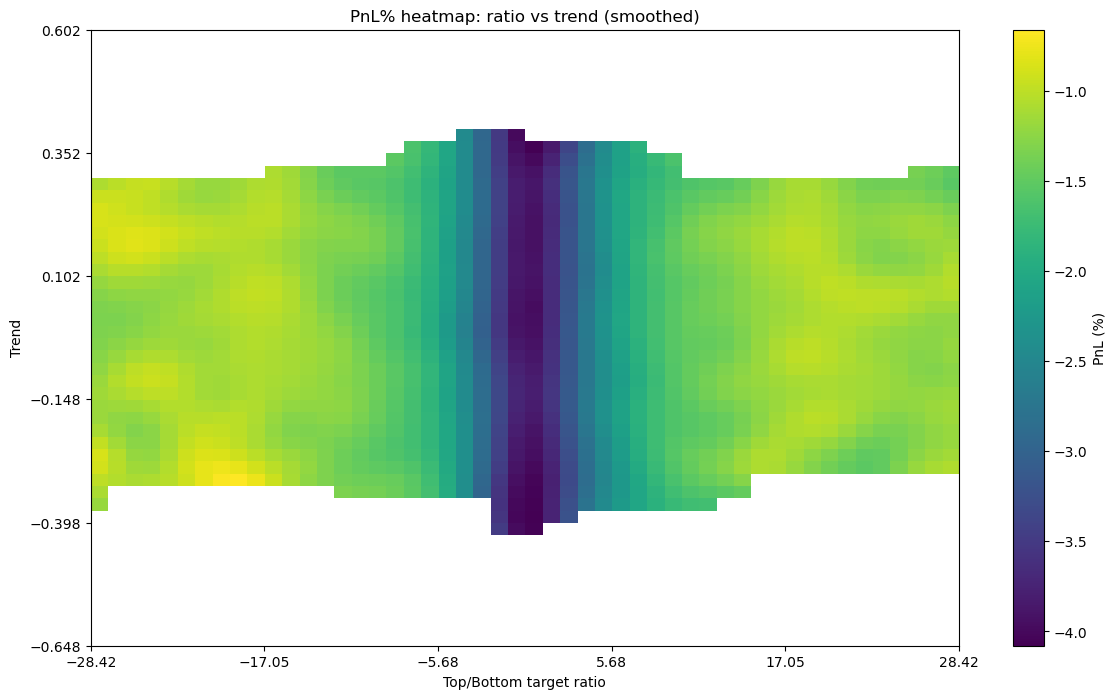

In [5]:
# Heatmap: PnL% vs Top/Bottom ratio and Trend (smoothed)
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.ndimage import gaussian_filter

# Collect points: x=top/bottom target ratio, y=trend, z=PnL%
points = []

for item in test_data:
    rc = item['run_conf']
    stat = item['stat']
    agg = item['stat']['agg']

    d_top = float(rc['d_top_target_perc'])
    d_btm = float(rc['d_btm_target_perc'])
    assert d_btm > 0.0, 'Bottom target percent must be positive'

    ratio = d_top / d_btm - 1 if d_top > d_btm else 1 - d_btm / d_top
    trend = float(item['t'])

    pnl_usd = float(agg['pnl'])
    vol_usd = float(rc['test_volume_usd'])
    assert vol_usd > 0.0, 'Test volume USD must be positive'

    pnl_pct = pnl_usd / vol_usd * 100.0

    points.append((ratio, trend, pnl_pct))

pts = np.array(points, dtype=np.float64)
assert pts.shape[0] > 0 and pts.shape[1] == 3, 'No points collected for heatmap'

x = pts[:, 0]
y = pts[:, 1]
z = pts[:, 2]

# Grid and binning (mean)
nx = 50
ny = 50

x_edges = np.linspace(np.min(x), np.max(x), nx + 1)
y_edges = np.linspace(np.min(y), np.max(y), ny + 1)

stat, _, _, _ = binned_statistic_2d(x, y, z, statistic='mean', bins=[x_edges, y_edges])

# Smooth
sigma = 1.5
stat_smooth = gaussian_filter(stat, sigma=sigma, mode='nearest')

# Centers and extent for real-value axes
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
extent = [float(np.min(x_centers)), float(np.max(x_centers)), float(np.min(y_centers)), float(np.max(y_centers))]

# Plot via matplotlib with real axes
plt.clf()
plt.figure(figsize=(14, 8))

im = plt.imshow(stat_smooth.T, origin='lower', aspect='auto', extent=extent, cmap='viridis')

plt.xlabel('Top/Bottom target ratio')
plt.ylabel('Trend')
plt.title('PnL% heatmap: ratio vs trend (smoothed)')

# Add readable ticks from real centers
xt = np.linspace(x_centers.min(), x_centers.max(), 6)
yt = np.linspace(y_centers.min(), y_centers.max(), 6)
plt.xticks(xt)
plt.yticks(yt)

cbar = plt.colorbar(im)
cbar.set_label('PnL (%)')

plt.show()


<Figure size 640x480 with 0 Axes>

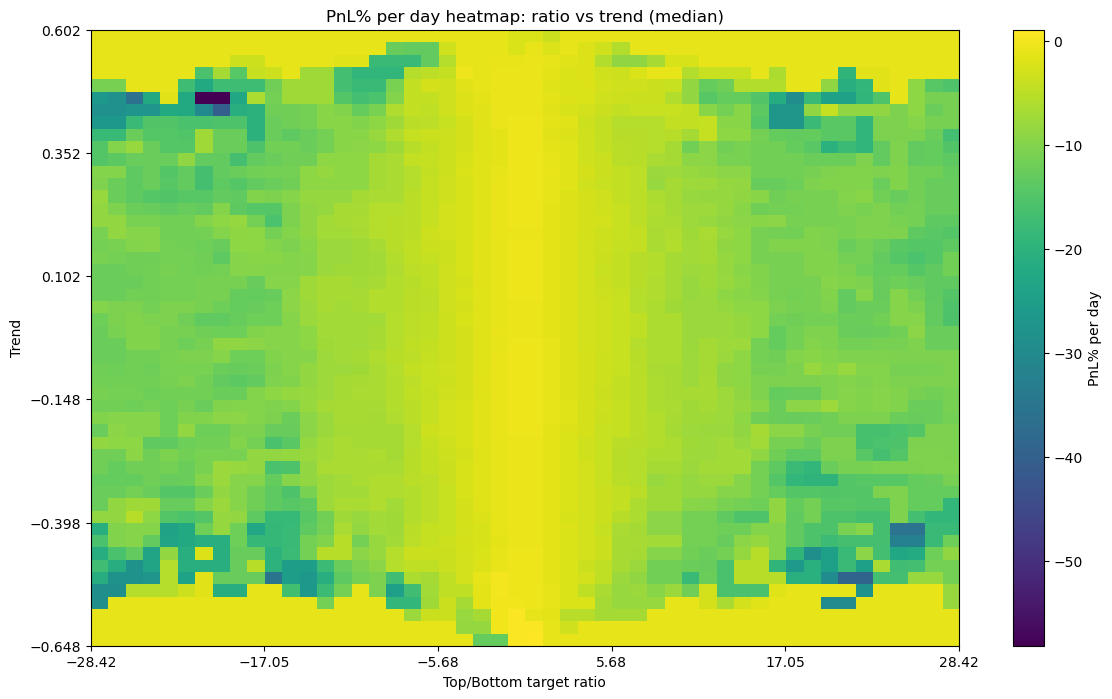

In [6]:
# Heatmap: PnL% per day vs Top/Bottom ratio and Trend (median + median filter)
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.ndimage import median_filter

# Collect points: x=top/bottom target ratio, y=trend, z=PnL% per day
points = []

for item in test_data:
    assert 'run_conf' in item and 'stat' in item, 'Missing required fields in test item'

    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    d_top = float(rc['d_top_target_perc'])
    d_btm = float(rc['d_btm_target_perc'])
    assert d_btm > 0.0, 'Bottom target percent must be positive'

    ratio = d_top / d_btm - 1 if d_top > d_btm else 1 - d_btm / d_top
    trend = float(item['t'])

    pnl_usd = float(agg['pnl'])
    vol_usd = float(rc['test_volume_usd'])
    assert vol_usd > 0.0, 'Test volume USD must be positive'

    dur_s = float(agg['full_execution_time'])
    assert dur_s > 0.0, 'Full execution time must be positive'

    pnl_pct_per_day = (pnl_usd / vol_usd) / (dur_s / 86400.0) * 100.0

    points.append((ratio, trend, pnl_pct_per_day))

pts = np.array(points, dtype=np.float64)
assert pts.shape[0] > 0 and pts.shape[1] == 3, 'No points collected for heatmap'

x = pts[:, 0]
y = pts[:, 1]
z = pts[:, 2]

# Grid and per-bin median
nx = 50
ny = 50

x_edges = np.linspace(np.min(x), np.max(x), nx + 1)
y_edges = np.linspace(np.min(y), np.max(y), ny + 1)

stat, _, _, _ = binned_statistic_2d(x, y, z, statistic='median', bins=[x_edges, y_edges])

# Replace NaNs with global median to avoid empty-bin artifacts
z_global_median = float(np.median(z))
stat_filled = np.array(stat, dtype=np.float64)
stat_filled[np.isnan(stat_filled)] = z_global_median

# Median filter smoothing to suppress spikes
stat_smooth = median_filter(stat_filled, size=3, mode='nearest')

# Centers and extent for real-value axes
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
extent = [float(np.min(x_centers)), float(np.max(x_centers)), float(np.min(y_centers)), float(np.max(y_centers))]

# Plot via matplotlib with real axes
plt.clf()
plt.figure(figsize=(14, 8))

im = plt.imshow(stat_smooth.T, origin='lower', aspect='auto', extent=extent, cmap='viridis')

plt.xlabel('Top/Bottom target ratio')
plt.ylabel('Trend')
plt.title('PnL% per day heatmap: ratio vs trend (median)')

# Add readable ticks from real centers
xt = np.linspace(x_centers.min(), x_centers.max(), 6)
yt = np.linspace(y_centers.min(), y_centers.max(), 6)
plt.xticks(xt)
plt.yticks(yt)

cbar = plt.colorbar(im)
cbar.set_label('PnL% per day')

plt.show()


<Figure size 640x480 with 0 Axes>

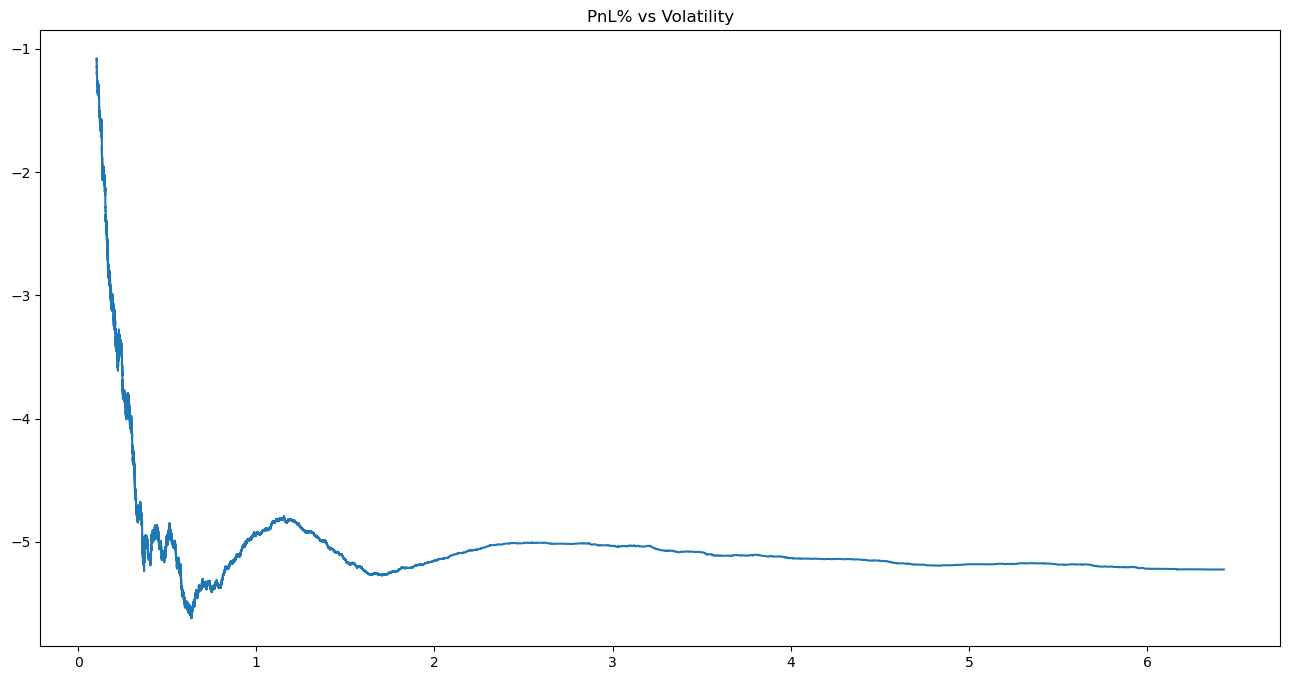

In [7]:
# PnL% vs Volatility (pairs)
import numpy as np

pairs = []

for item in test_data:
    assert 'run_conf' in item and 'stat' in item and 'v' in item, 'Missing required fields in test item'

    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    vol = float(item['v'])
    assert np.isfinite(vol), 'Volatility must be finite'

    pnl_usd = float(agg['pnl'])
    vol_usd = float(rc['test_volume_usd'])
    assert vol_usd > 0.0, 'Test volume USD must be positive'

    pnl_pct = pnl_usd / vol_usd * 100.0

    pairs.append((vol, pnl_pct))

assert len(pairs) > 0, 'No pairs collected for volatility plot'

plot_pairs(pairs, title='PnL% vs Volatility', log_x=False)


<Figure size 640x480 with 0 Axes>

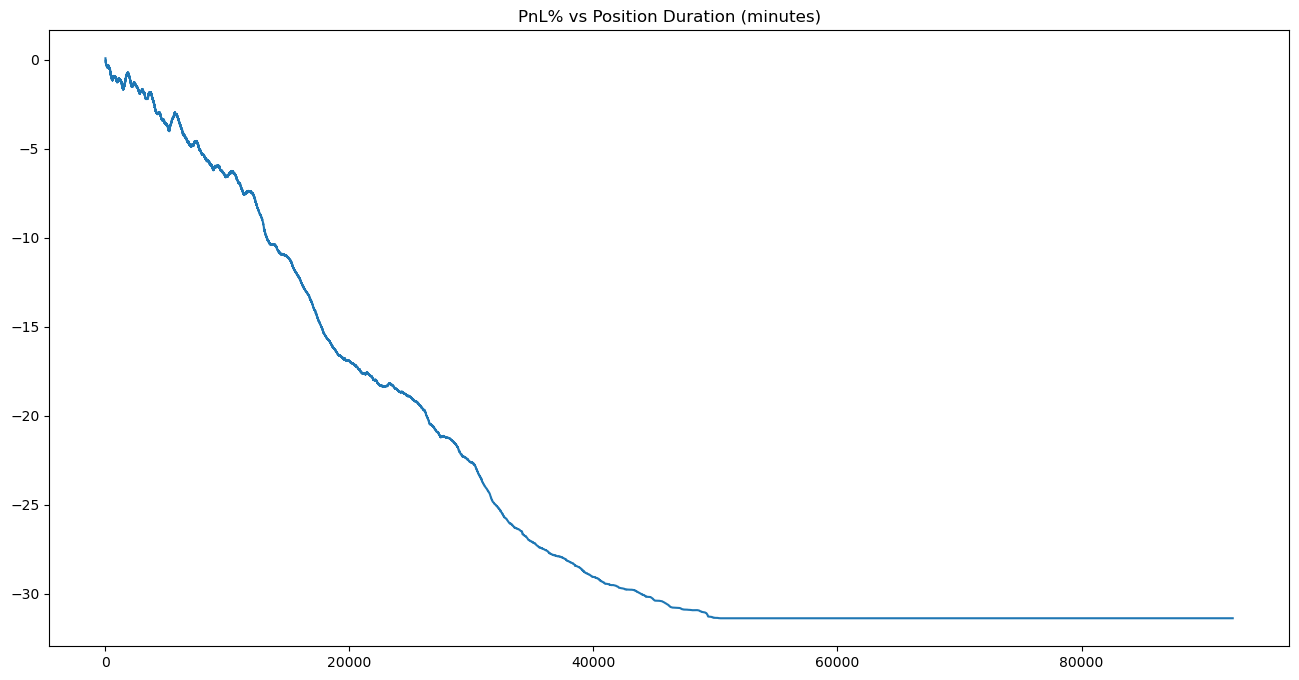

In [8]:
# PnL% vs Position Duration (minutes) (pairs)
import numpy as np

pairs = []

for item in test_data:
    assert 'run_conf' in item and 'stat' in item, 'Missing required fields in test item'

    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    dur_s = float(agg['full_execution_time'])
    assert dur_s > 0.0, 'Full execution time must be positive'

    dur_min = dur_s / 60
   
    pnl_usd = float(agg['pnl'])
    vol_usd = float(rc['test_volume_usd'])
    assert vol_usd > 0.0, 'Test volume USD must be positive'

    pnl_pct = pnl_usd / vol_usd * 100.0

    pairs.append((dur_min, pnl_pct))

assert len(pairs) > 0, 'No pairs collected for duration plot'

plot_pairs(pairs, title='PnL% vs Position Duration (minutes)', log_x=False)


Median PnL per day: -2.225198 %/day, based on 104084 tests


<Figure size 640x480 with 0 Axes>

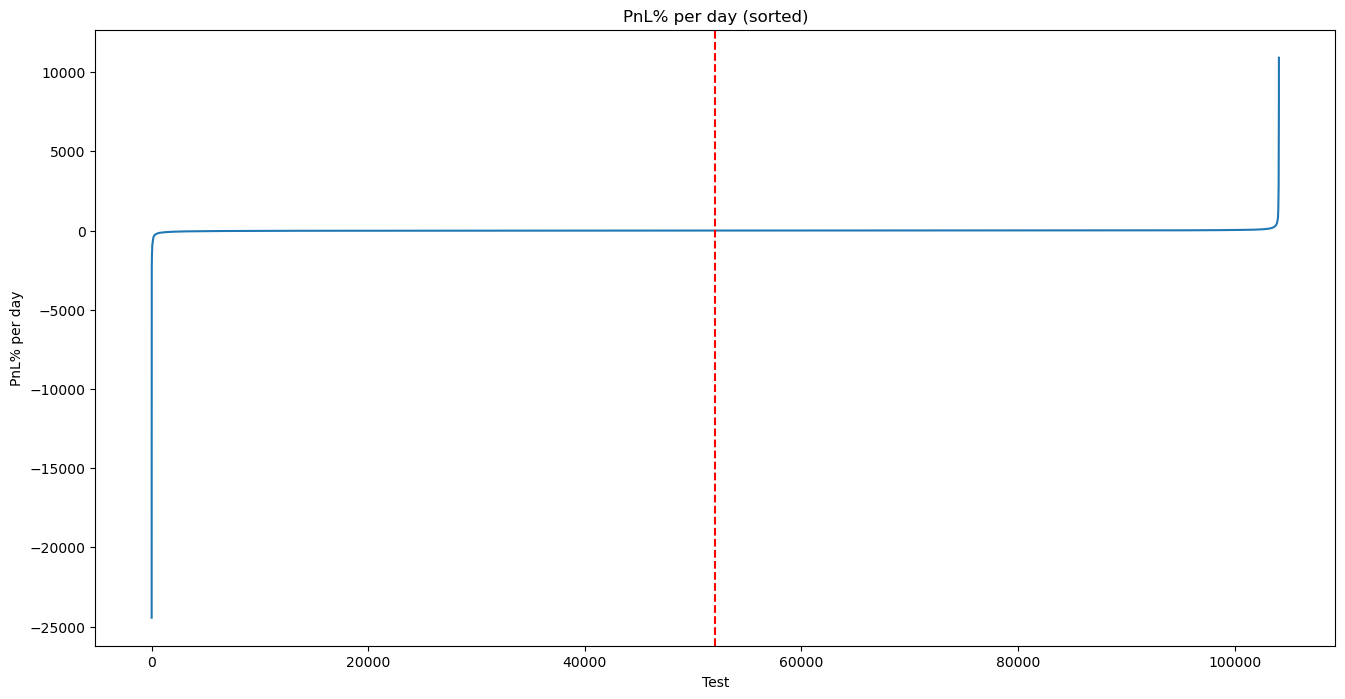

In [ ]:
# Median PnL% per day (filtered by test volume)
import numpy as np

# Filter by test volume (USD)
TEST_VOLUME_FROM = 100_000
TEST_VOLUME_TO = 1e7

# Filter by diameter (percent): d_top_target_perc + d_btm_target_perc
DIAMETER_PERC_FROM = 10
DIAMETER_PERC_TO = 12

assert TEST_VOLUME_FROM >= 0.0, 'TEST_VOLUME_FROM must be non-negative'
assert TEST_VOLUME_TO >= TEST_VOLUME_FROM, 'TEST_VOLUME_TO must be >= TEST_VOLUME_FROM'
assert DIAMETER_PERC_FROM >= 0.0, 'DIAMETER_PERC_FROM must be non-negative'
assert DIAMETER_PERC_TO >= DIAMETER_PERC_FROM, 'DIAMETER_PERC_TO must be >= DIAMETER_PERC_FROM'

pnls_pct_per_day = []
tmp = []

for item in test_data:
    assert 'run_conf' in item and 'stat' in item, 'Missing required fields in test item'

    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    pnl_usd = float(agg['pnl'])
    vol_usd = float(rc['test_volume_usd'])
    assert vol_usd > 0.0, 'Test volume USD must be positive'

    if not (TEST_VOLUME_FROM <= vol_usd <= TEST_VOLUME_TO):
        continue

    d_top = float(rc['d_top_target_perc'])
    d_btm = float(rc['d_btm_target_perc'])
    assert d_top > 0.0 and d_btm > 0.0, 'Target percents must be positive'

    diameter = d_top + d_btm
    if not (DIAMETER_PERC_FROM <= diameter <= DIAMETER_PERC_TO):
        continue

    dur_s = float(agg['full_execution_time'])
    assert dur_s > 0.0, 'Full execution time must be positive'

    pct_per_day = (pnl_usd / vol_usd) / (dur_s / 86400.0) * 100.0

    pnls_pct_per_day.append(pct_per_day)
    tmp.append((pct_per_day, pnl_usd, vol_usd, d_top, d_btm, dur_s))

assert len(pnls_pct_per_day) > 0, 'No data to compute PnL% per day'

median_pct_per_day = float(np.median(np.array(pnls_pct_per_day, dtype=np.float64)))

print(f'Median PnL per day: {median_pct_per_day:.6f} %/day, based on {len(pnls_pct_per_day)} tests')

plt.clf()
plt.figure(figsize=(16, 8))
plt.plot(sorted(pnls_pct_per_day))
plt.title('PnL% per day (sorted)')
plt.xlabel('Test')
plt.ylabel('PnL% per day')
plt.axvline(x=len(pnls_pct_per_day) * 0.5, color='red', linestyle='--', label='Median')
plt.show()


<Figure size 640x480 with 0 Axes>

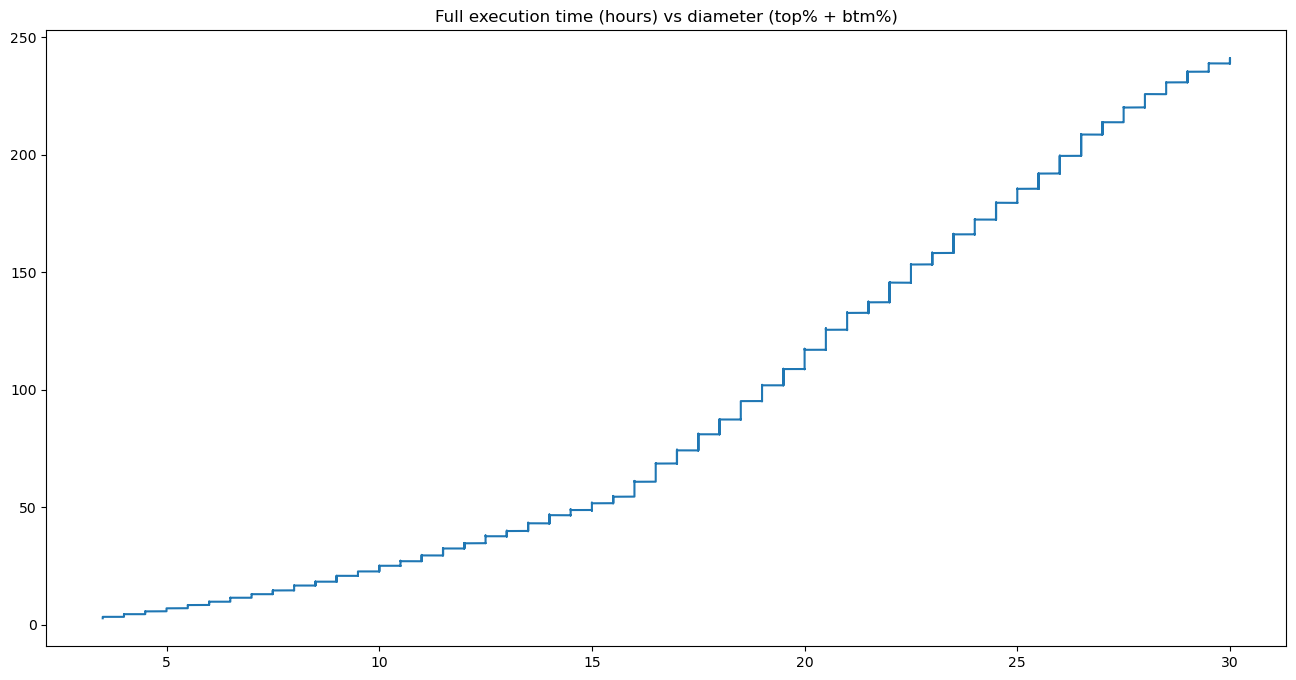

In [10]:
# Full execution time vs diameter (top% + bottom%) (pairs)
pairs = []

for item in test_data:
    assert 'run_conf' in item and 'stat' in item, 'Missing required fields in test item'

    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    d_top = float(rc['d_top_target_perc'])
    d_btm = float(rc['d_btm_target_perc'])
    assert d_top > 0.0 and d_btm > 0.0, 'Target percents must be positive'

    diameter = d_top + d_btm

    dur_s = float(agg['full_execution_time'])
    assert dur_s > 0.0, 'Full execution time must be positive'

    dur_hours = dur_s / 3600.0

    pairs.append((diameter, dur_hours))

assert len(pairs) > 0, 'No pairs collected for diameter/time plot'

plot_pairs(pairs, title='Full execution time (hours) vs diameter (top% + btm%)', log_x=False)


<Figure size 640x480 with 0 Axes>

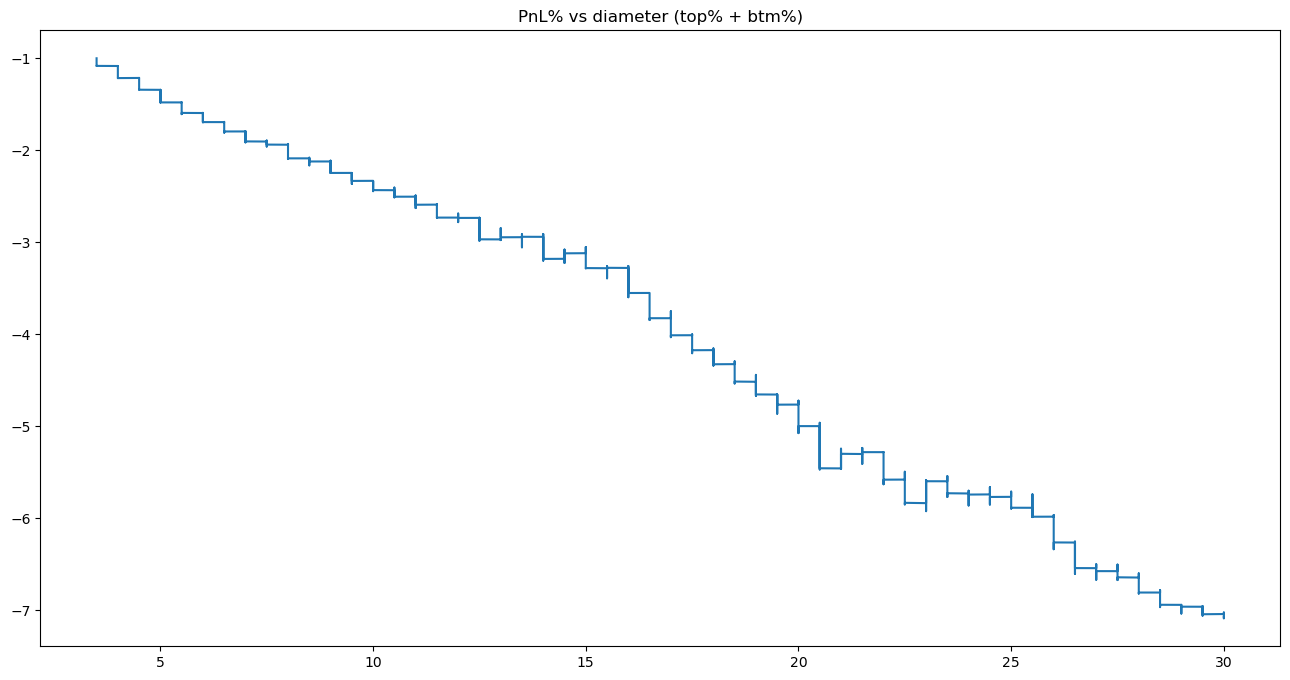

In [11]:
# PnL% vs diameter (top% + bottom%) (pairs)
import numpy as np

pairs = []

for item in test_data:
    assert 'run_conf' in item and 'stat' in item, 'Missing required fields in test item'

    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    d_top = float(rc['d_top_target_perc'])
    d_btm = float(rc['d_btm_target_perc'])
    assert d_top > 0.0 and d_btm > 0.0, 'Target percents must be positive'

    diameter = d_top + d_btm

    pnl_usd = float(agg['pnl'])
    vol_usd = float(rc['test_volume_usd'])
    assert vol_usd > 0.0, 'Test volume USD must be positive'

    pnl_pct = pnl_usd / vol_usd * 100.0

    pairs.append((diameter, pnl_pct))

assert len(pairs) > 0, 'No pairs collected for PnL% vs diameter plot'

plot_pairs(pairs, title='PnL% vs diameter (top% + btm%)', log_x=False)


<Figure size 640x480 with 0 Axes>

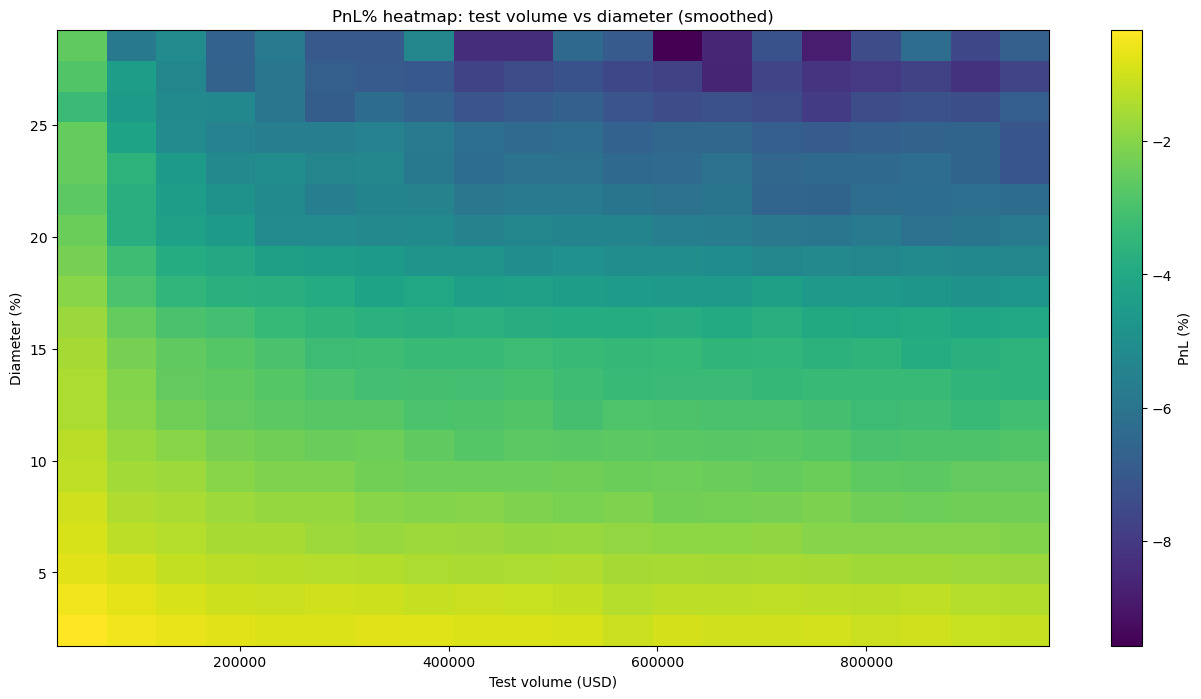

In [12]:
# Heatmap: PnL% vs Test Volume (USD) and Diameter (smoothed, no filters)
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.ndimage import gaussian_filter

# Collect points: x=test volume USD, y=diameter (top%+btm%), z=PnL%
points = []

for item in test_data:
    assert 'run_conf' in item and 'stat' in item, 'Missing required fields in test item'

    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    vol_usd = float(rc['test_volume_usd'])
    assert vol_usd > 0.0, 'Test volume USD must be positive'

    d_top = float(rc['d_top_target_perc'])
    d_btm = float(rc['d_btm_target_perc'])
    assert d_top > 0.0 and d_btm > 0.0, 'Target percents must be positive'

    diameter = d_top + d_btm

    pnl_usd = float(agg['pnl'])
    pnl_pct = pnl_usd / vol_usd * 100.0

    points.append((vol_usd, diameter, pnl_pct))

pts = np.array(points, dtype=np.float64)
assert pts.shape[0] > 0 and pts.shape[1] == 3, 'No points collected for heatmap'

x = pts[:, 0]
y = pts[:, 1]
z = pts[:, 2]

# Grid and binning (mean)
nx = 20
ny = 20

x_edges = np.linspace(np.min(x), np.max(x), nx + 1)
y_edges = np.linspace(np.min(y), np.max(y), ny + 1)

stat, _, _, _ = binned_statistic_2d(x, y, z, statistic='mean', bins=[x_edges, y_edges])

# Smooth
sigma = 0.5
stat_smooth = gaussian_filter(stat, sigma=sigma, mode='nearest')

# Centers and extent for axes
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
extent = [float(np.min(x_centers)), float(np.max(x_centers)), float(np.min(y_centers)), float(np.max(y_centers))]

# Plot via matplotlib
plt.clf()
plt.figure(figsize=(16, 8))

im = plt.imshow(stat_smooth.T, origin='lower', aspect='auto', extent=extent, cmap='viridis')

plt.xlabel('Test volume (USD)')
plt.ylabel('Diameter (%)')
plt.title('PnL% heatmap: test volume vs diameter (smoothed)')

cbar = plt.colorbar(im)
cbar.set_label('PnL (%)')

plt.show()


<Figure size 640x480 with 0 Axes>

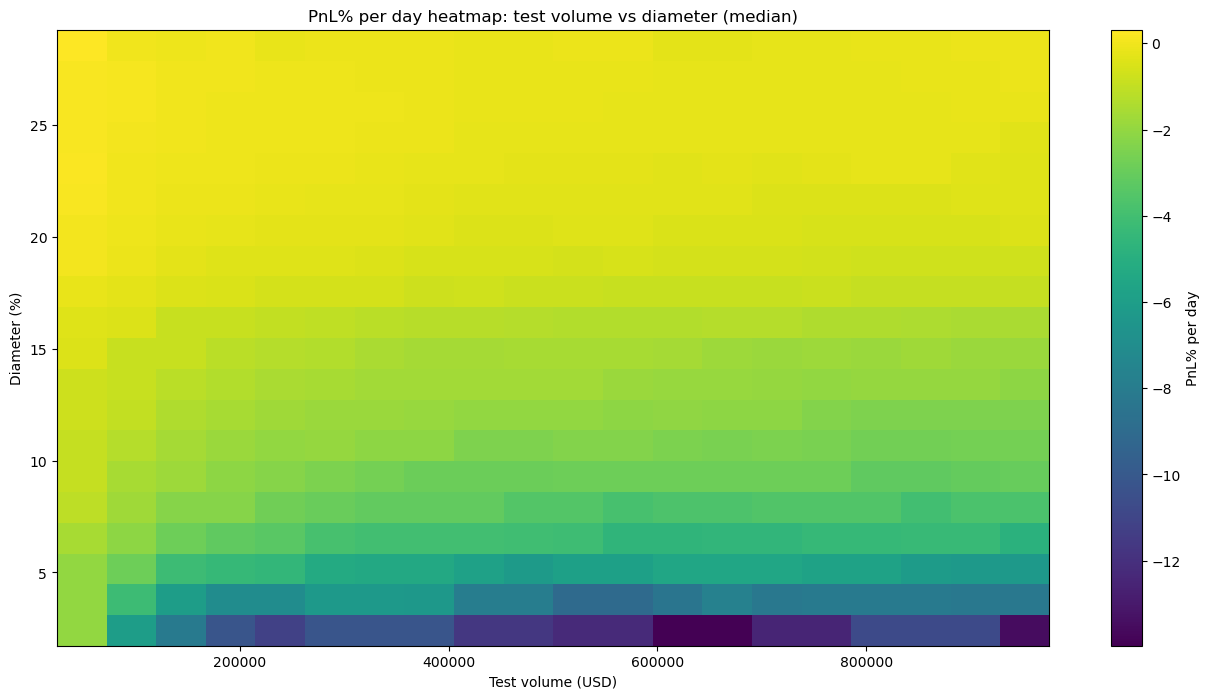

In [13]:
# Heatmap: PnL% per day vs Test Volume (USD) and Diameter (median + median filter)
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.ndimage import median_filter

# Collect points: x=test volume USD, y=diameter (top%+btm%), z=PnL% per day
points = []

for item in test_data:
    assert 'run_conf' in item and 'stat' in item, 'Missing required fields in test item'

    rc = item['run_conf']
    stat = item['stat']
    agg = stat['agg']

    vol_usd = float(rc['test_volume_usd'])
    assert vol_usd > 0.0, 'Test volume USD must be positive'

    d_top = float(rc['d_top_target_perc'])
    d_btm = float(rc['d_btm_target_perc'])
    assert d_top > 0.0 and d_btm > 0.0, 'Target percents must be positive'

    diameter = d_top + d_btm

    pnl_usd = float(agg['pnl'])
    dur_s = float(agg['full_execution_time'])
    assert dur_s > 0.0, 'Full execution time must be positive'

    pct_per_day = (pnl_usd / vol_usd) / (dur_s / 86400.0) * 100.0

    points.append((vol_usd, diameter, pct_per_day))

pts = np.array(points, dtype=np.float64)
assert pts.shape[0] > 0 and pts.shape[1] == 3, 'No points collected for heatmap'

x = pts[:, 0]
y = pts[:, 1]
z = pts[:, 2]

# Grid and per-bin median
nx = 20
ny = 20

x_edges = np.linspace(np.min(x), np.max(x), nx + 1)
y_edges = np.linspace(np.min(y), np.max(y), ny + 1)

stat, _, _, _ = binned_statistic_2d(x, y, z, statistic='median', bins=[x_edges, y_edges])

# Fill empty bins with global median to avoid NaN propagation
z_global_median = float(np.median(z))
stat_filled = np.array(stat, dtype=np.float64)
stat_filled[np.isnan(stat_filled)] = z_global_median

# Median filter smoothing to suppress outliers
stat_smooth = median_filter(stat_filled, size=3, mode='nearest')

# Centers and extent for axes
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
extent = [float(np.min(x_centers)), float(np.max(x_centers)), float(np.min(y_centers)), float(np.max(y_centers))]

# Plot via matplotlib
plt.clf()
plt.figure(figsize=(16, 8))

im = plt.imshow(stat_smooth.T, origin='lower', aspect='auto', extent=extent, cmap='viridis')

plt.xlabel('Test volume (USD)')
plt.ylabel('Diameter (%)')
plt.title('PnL% per day heatmap: test volume vs diameter (median)')

cbar = plt.colorbar(im)
cbar.set_label('PnL% per day')

plt.show()
